# Exercice partie 3 - Analysez des données de systèmes éducatifs

In [515]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [516]:
data = pd.read_csv('data/data_formated.csv', sep=',')
data = data.set_index('Country Name')

data.rename(columns={
    'Enrolment in secondary education, both sexes (number)': 'enrolment_secondary',
    'Gross enrolment ratio, secondary, both sexes (%)': 'enrolment_ratio_secondary',
    'Gross enrolment ratio, upper secondary, both sexes (%)': 'enrolment_ratio_upper_secondary',
    'Population of the official age for tertiary education, both sexes (number)': 'pop_age_tertiary',
    'Population of the official age for upper secondary education, both sexes (number)': 'pop_age_upper_secondary',
    'Population, age 15, total': 'pop_age_15',
    'Population, age 16, total': 'pop_age_16',
    'Population, age 17, total': 'pop_age_17',
    'Population, age 18, total': 'pop_age_18',
    'Population, age 19, total': 'pop_age_19',
    'Population, age 20, total': 'pop_age_20',
    'Population, age 21, total': 'pop_age_21',
    'Population, age 22, total': 'pop_age_22',
    'Population, age 23, total': 'pop_age_23',
    'Population, age 24, total': 'pop_age_24',
}, inplace=True)

## Etape 1 - Identifiez les indicateurs redondants d'un point de vue statistique

In [517]:
# Calculez une matrice de corrélation entre l’ensemble des indicateurs en utilisant la méthode de Pearson puis de Spearman

# Méthode de Pearson
pearson_matrix = data.corr()
pearson_matrix

,enrolment_secondary,enrolment_ratio_secondary,enrolment_ratio_upper_secondary,pop_age_tertiary,pop_age_upper_secondary,pop_age_15,pop_age_16,pop_age_17,pop_age_18,pop_age_19,pop_age_20,pop_age_21,pop_age_22,pop_age_23,pop_age_24
enrolment_secondary,1.00,0.01,-0.00,0.99,0.98,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
enrolment_ratio_secondary,0.01,1.00,0.96,-0.03,-0.05,-0.05,-0.05,-0.05,-0.05,-0.04,-0.04,-0.03,-0.03,-0.03,-0.03
enrolment_ratio_upper_secondary,-0.00,0.96,1.00,-0.04,-0.06,-0.06,-0.06,-0.06,-0.06,-0.05,-0.05,-0.04,-0.04,-0.04,-0.04
pop_age_tertiary,0.99,-0.03,-0.04,1.00,0.96,0.99,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00
pop_age_upper_secondary,0.98,-0.05,-0.06,0.96,1.00,0.99,0.98,0.98,0.98,0.98,0.97,0.97,0.96,0.96,0.96
pop_age_15,0.99,-0.05,-0.06,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.99,0.99
pop_age_16,0.99,-0.05,-0.06,0.99,0.98,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.99
pop_age_17,0.99,-0.05,-0.06,0.99,0.98,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.99
pop_age_18,0.99,-0.05,-0.06,1.00,0.98,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
pop_age_19,0.99,-0.04,-0.05,1.00,0.98,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [518]:
# Méthode de Spearman

spearman_matrix = data.corr('spearman')
spearman_matrix

,enrolment_secondary,enrolment_ratio_secondary,enrolment_ratio_upper_secondary,pop_age_tertiary,pop_age_upper_secondary,pop_age_15,pop_age_16,pop_age_17,pop_age_18,pop_age_19,pop_age_20,pop_age_21,pop_age_22,pop_age_23,pop_age_24
enrolment_secondary,1.00,0.01,0.02,0.97,0.96,0.96,0.96,0.96,0.96,0.97,0.97,0.97,0.97,0.97,0.97
enrolment_ratio_secondary,0.01,1.00,0.95,-0.16,-0.20,-0.23,-0.22,-0.21,-0.20,-0.19,-0.19,-0.17,-0.16,-0.16,-0.15
enrolment_ratio_upper_secondary,0.02,0.95,1.00,-0.15,-0.18,-0.22,-0.21,-0.20,-0.19,-0.18,-0.17,-0.16,-0.15,-0.14,-0.13
pop_age_tertiary,0.97,-0.16,-0.15,1.00,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
pop_age_upper_secondary,0.96,-0.20,-0.18,0.99,1.00,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
pop_age_15,0.96,-0.23,-0.22,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.99
pop_age_16,0.96,-0.22,-0.21,1.00,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.99
pop_age_17,0.96,-0.21,-0.20,1.00,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99
pop_age_18,0.96,-0.20,-0.19,1.00,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
pop_age_19,0.97,-0.19,-0.18,1.00,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


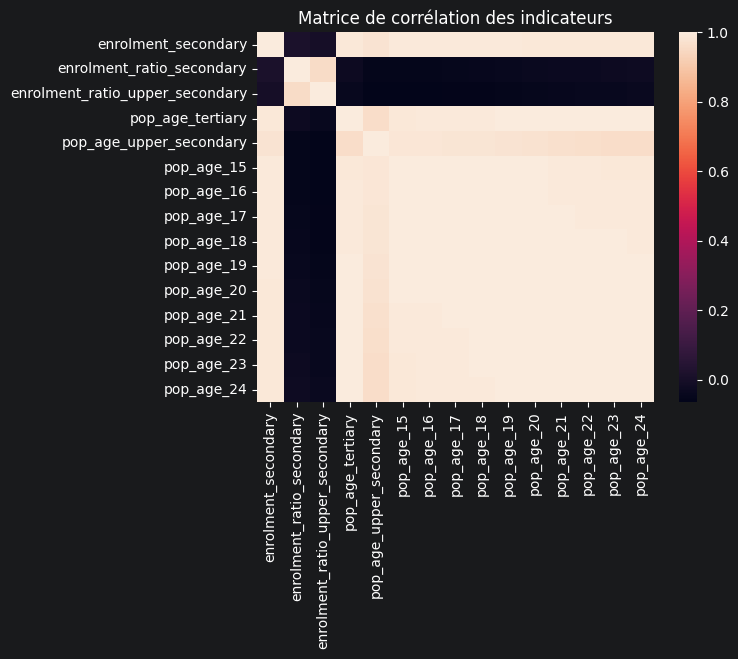

In [519]:
sns.heatmap(data=pearson_matrix)
plt.title('Matrice de corrélation des indicateurs')
plt.show()

<Axes: >

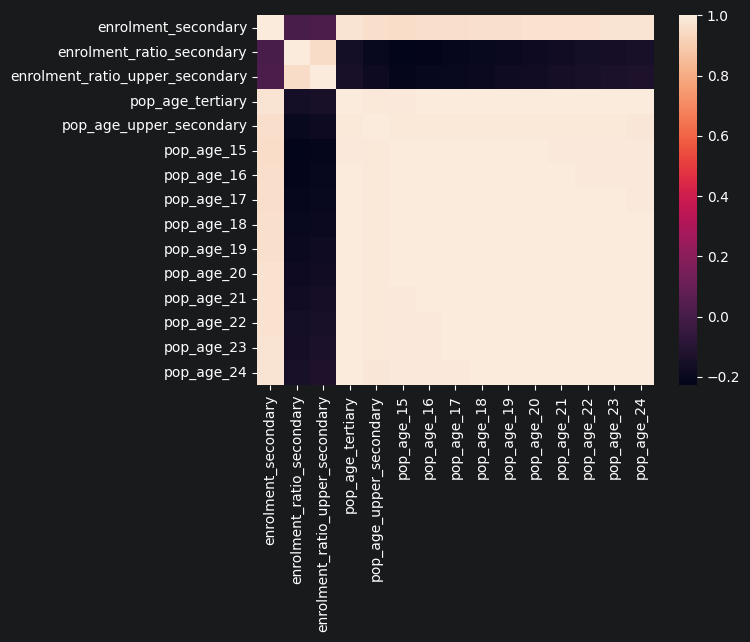

In [520]:
sns.heatmap(data=spearman_matrix)

On remarque sur la heatmap que "Gross enrolment ratio, secondary, both sexes" et "Gross enrolment ratio, upper secondary, both sexes" sont fortément corrélé (même couleurs),
l'indicateur "upper secondary" représente le lycée alors que "secondary" représente collège et lycée., vu que l'ont cherche a cibler Lycée et Université dans le cadre de notre Edtech, je vais supprimer l'indictauer secondary qui n'as pas de valeur ajoutée.

In [521]:
data.drop(columns='enrolment_ratio_secondary', inplace=True)

De la même manière, grâce à la heatmap, on remarque un gros carée blanc en bas à droite de la carte. Tous les indicateurs d'ages sont fortement corrélés.
Je vais fusionner les tranches d'âge afin de ne garder qu'un seul indicateur age_15_24 qui contizent la somme des indicateurs d'ages.


In [522]:
data['age_15_24'] = data.iloc[:, -10:].sum(axis=1)
cols_a_supprimer = data.columns[-11:-1]
data.drop(columns=cols_a_supprimer, inplace=True)

<Axes: >

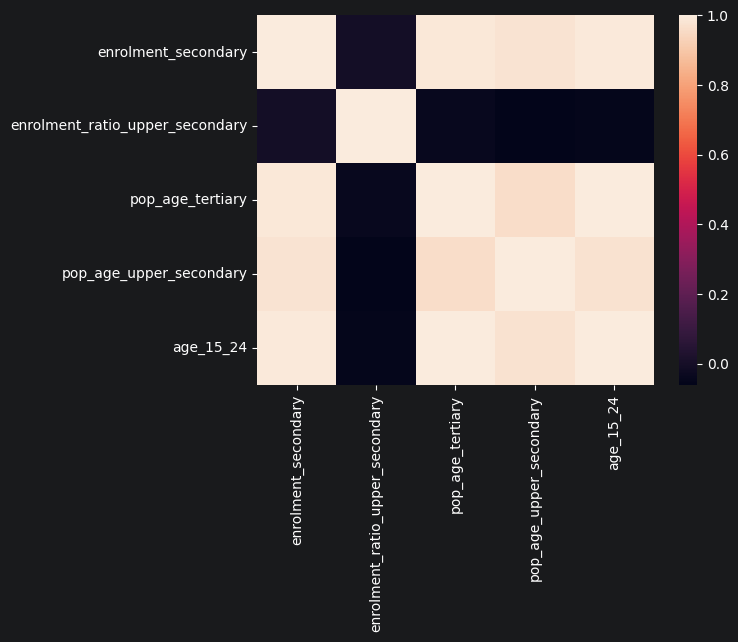

In [523]:
sns.heatmap(data=data.corr(method='pearson'))

On remarque que le "Gross enrolment ratio, upper secondary, both sexes (%) se démarque des autre il est donc fortement décorrélé des autres indicateurs.
En revanche tout les autres sont très corrélé.

Par exemple "Population of the official age for tertiary education" est forcément très corrélé avec age_15_24 ce qui semble logique puisque les population vont se retrouver dans les 2 catégories.

De mon point de vue age_24_25 est important pour nous, car il détermine le public cible de notre marché.
Je décide donc de ne garder que :
- age_24_25
- enrolment_ratio_upper_secondary


In [541]:
final_data = data[['enrolment_ratio_upper_secondary', 'age_15_24']]

## Etape 2 - Analysez vos indicateurs restants et formulez une liste de pays pertinents pour l'implantation d'Academy

In [542]:
# Choisissez un indicateur (celui que vous voulez) et calculez ses statistiques descriptives basiques puis tracez sa distribution.
def describe_indicator(data, indicator_label):
    print(data.describe())

    sns.displot(data)

    plt.xlabel(indicator_label, fontsize=12)
    plt.ylabel("Nombre de pays", fontsize=12)

    plt.show()

Index(['enrolment_ratio_upper_secondary', 'age_15_24'], dtype='str')
count   160.00
mean     73.70
std      33.86
min       7.47
25%      42.24
50%      80.48
75%      95.56
max     178.56
Name: enrolment_ratio_upper_secondary, dtype: float64


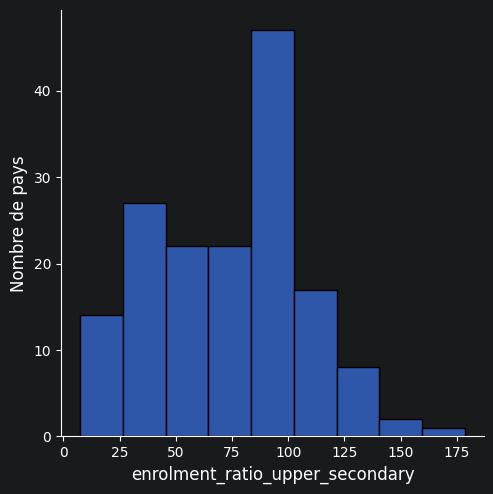

count         180.00
mean      6715296.63
std      24438656.36
min         13783.60
25%        503671.10
50%       1319282.00
75%       4961708.25
max     239594829.00
Name: age_15_24, dtype: float64


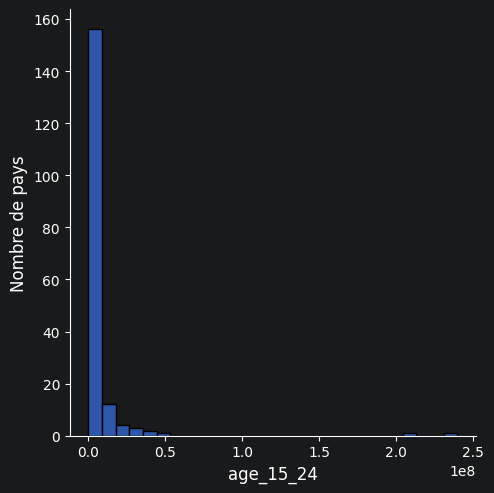

In [543]:
print(final_data.columns)
for col in final_data.columns:
    describe_indicator(final_data[col], col)

### Analyse de l'indicateur "age_15_24" :

La distribution déformée par les outliners

In [544]:
final_data.sort_values('age_15_24', ascending=False).head(5)

,enrolment_ratio_upper_secondary,age_15_24
Country Name,,
India,57.53,239594829.00
China,81.34,210099514.80
United States,90.82,45246251.80
Indonesia,71.52,41974836.20
Pakistan,30.10,39171669.00


En effet la Chine et l'Inde écrasent les autres pays.

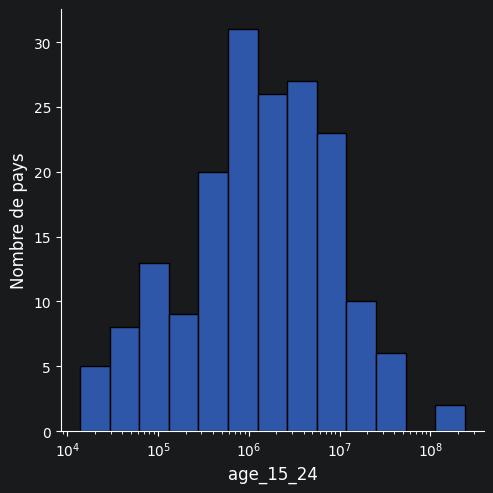

In [545]:
# On ajoute log_scale pour retrouver une distribution moins affectée par ces deux outliners
sns.displot(data['age_15_24'], log_scale=True)

plt.xlabel('age_15_24', fontsize=12)
plt.ylabel("Nombre de pays", fontsize=12)

plt.show()

De cette manière on retrouve une distribution normale.

### Analyse de l'indicateur "Gross enrolment ratio, upper secondary, both sexes (%)" :

La médiane à 80.48% nous indique que 50% des pays atteigne 80% de scolarisation dans Lycée.
Ces pays sont très intéréssant pour notre Edtech.


In [546]:
# Proposez une méthode quantitative, sur la base des indicateurs, pour sélectionner des pays et répondre à la demande de Mark

# Je vais essayer de prendre les 20 premiers de chaque indicateur et croiser les listes pour voir si des pays se démarquent
final_data.sort_values('age_15_24', ascending=False, inplace=True)
most_populated_countries = final_data.iloc[0:20]

final_data.sort_values('enrolment_ratio_upper_secondary', ascending=False, inplace=True)
most_gross_enrolment_countries = final_data.iloc[0:20]

selected_countries = set(most_populated_countries.index.tolist()) & set(most_gross_enrolment_countries.index.tolist())
print(f'Nombre de pays : {len(selected_countries)}')


Nombre de pays : 0


Aucun pays ne ressort dans le top 20 selon les indicateurs de population et de taux de scolarisation.

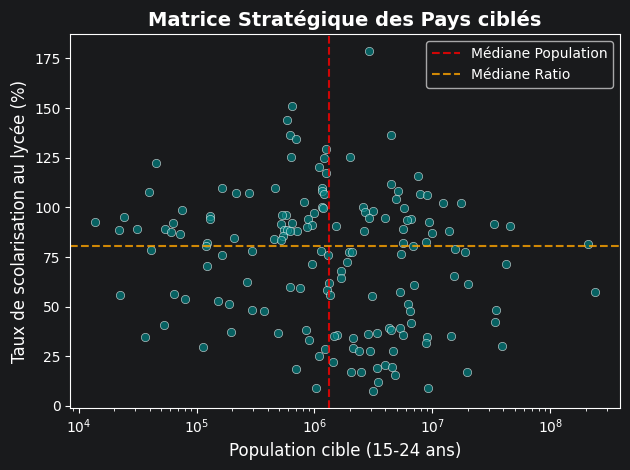

In [547]:
sns.scatterplot(data=final_data,
                x='age_15_24',
                y='enrolment_ratio_upper_secondary',
                alpha=0.7,
                color='teal')

# Echelle log pour eviter que le graphique soit écrasé a cause des outliner Inde et Chine sur l'indicateur age_15_24
plt.xscale('log')

# Affichage des mediane pour diviser les graphiques en 4 sections
median_pop = final_data['age_15_24'].median()
median_ratio = final_data['enrolment_ratio_upper_secondary'].median()
plt.axvline(median_pop, color='red', linestyle='--', alpha=0.8, label='Médiane Population')
plt.axhline(median_ratio, color='orange', linestyle='--', alpha=0.8, label='Médiane Ratio')

plt.title("Matrice Stratégique des Pays ciblés", fontsize=14, fontweight='bold')
plt.xlabel("Population cible (15-24 ans)", fontsize=12)
plt.ylabel("Taux de scolarisation au lycée (%)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


Visuellement ici, on voit 4 sections :

La section en haut à gauche : Pays fortement scolarisé avec une faible population jeune.
Section en bas à gauche : Pays Faiblement scolarisé avec une faible population jeune.
Section en bas a droite : Pays faiblement scolarisé avec une forte population jeune.
Section en haut à gauche : Pays Fortement scolarisé à forte population jeune. (Notre cible prioritaire)

In [548]:
most_interesting_countries = final_data.loc[(final_data['age_15_24'] > median_pop) & (final_data['enrolment_ratio_upper_secondary'] > median_ratio)]
print(f'Nombre de pays intéréssant : {len(most_interesting_countries)}')

Nombre de pays intéréssant : 31


In [549]:
from sklearn.preprocessing import MinMaxScaler

# On doit normaliser les colonnes, car on ne peut pas fusionner des populations et des %age d'inscription.
scaler = MinMaxScaler()

columns_to_normalize = ['age_15_24', 'enrolment_ratio_upper_secondary']
most_interesting_countries[['population_score', 'enrolment_ratio_score']] = scaler.fit_transform(most_interesting_countries[columns_to_normalize])
most_interesting_countries['global_score'] = (most_interesting_countries['population_score'] + most_interesting_countries['enrolment_ratio_score']) / 2

# Tri par score décroissant
top_pays_finaux = most_interesting_countries.sort_values('global_score', ascending=False)

print(f'Nombre de pays sélectionnés : {len(top_pays_finaux)}')
# Top 20
top_pays_finaux[:10]


Nombre de pays sélectionnés : 31


,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score
Country Name,,,,,
China,81.34,210099514.80,1.00,0.01,0.50
Australia,178.56,2920804.40,0.01,1.00,0.50
Spain,136.44,4436945.40,0.01,0.57,0.29
Netherlands,125.56,2002184.00,0.00,0.46,0.23
France,115.59,7588616.60,0.03,0.36,0.19
Canada,111.74,4459604.40,0.01,0.32,0.17
United States,90.82,45246251.80,0.21,0.10,0.16
Saudi Arabia,108.31,5119918.20,0.02,0.28,0.15
United Kingdom,106.87,7923198.00,0.03,0.27,0.15


In [550]:
imported_series = pd.read_csv('data/EdStatsSeries.csv', sep=',')
imported_stats = pd.read_csv('data/EdStatsData.csv', sep=',')

In [551]:
series_code_topic_infrastructure = imported_series.loc[imported_series['Topic'] == 'Infrastructure: Communications']

indicators_infrastructure = imported_stats.loc[(imported_stats['Indicator Code'].isin(series_code_topic_infrastructure['Series Code'])) & (imported_stats['Country Name'].isin(top_pays_finaux.index.tolist()))]

import numpy as np
years = np.concatenate((np.arange(1970, 2010, 1), np.arange(2020, 2105, 5)))
cols = [str(col) for col in years]

indicators_infrastructure.drop(columns=cols, inplace=True)
indicators_infrastructure.drop(columns='2017', inplace=True)
indicators_infrastructure.drop(columns='Unnamed: 69', inplace=True)

In [552]:
indicators_infrastructure.set_index(['Country Name', 'Indicator Name']).isna().sum(axis=1)

# On a aucune donnée pour l'indicateur Personal computers (per 100 people) donc on ne garde pas cet indicateur
indicators_infrastructure = indicators_infrastructure[indicators_infrastructure['Indicator Name'] == 'Internet users (per 100 people)']

indicators_infrastructure


,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016
118655,Argentina,ARG,Internet users (per 100 people),IT.NET.USER.P2,45.00,51.00,55.80,59.90,64.70,68.04,70.15
129650,Australia,AUS,Internet users (per 100 people),IT.NET.USER.P2,76.00,79.49,79.00,83.45,84.00,84.56,88.24
188290,Brazil,BRA,Internet users (per 100 people),IT.NET.USER.P2,40.65,45.69,48.56,51.04,54.55,58.33,59.68
221275,Canada,CAN,Internet users (per 100 people),IT.NET.USER.P2,80.30,83.00,83.00,85.80,87.12,88.47,89.84
239600,Chile,CHL,Internet users (per 100 people),IT.NET.USER.P2,45.00,52.25,55.05,58.00,61.11,64.29,66.01
243265,China,CHN,Internet users (per 100 people),IT.NET.USER.P2,34.30,38.30,42.30,45.80,47.90,50.30,53.20
246930,Colombia,COL,Internet users (per 100 people),IT.NET.USER.P2,36.50,40.35,48.98,51.70,52.57,55.90,58.14
272585,Cuba,CUB,Internet users (per 100 people),IT.NET.USER.P2,15.90,16.02,21.20,27.93,29.07,37.31,38.77
301905,Ecuador,ECU,Internet users (per 100 people),IT.NET.USER.P2,29.03,31.37,35.14,40.28,45.59,48.94,54.06
338555,France,FRA,Internet users (per 100 people),IT.NET.USER.P2,77.28,77.82,81.44,81.92,83.75,84.69,85.62


In [553]:
years = ['2010', '2011', '2012', '2013', '2014', '2015', '2016']

# On ne garde que le max, la couverture d'internet ne pouvant pas (sauf catastrophe) diminuer
indicators_infrastructure['max_internet'] = indicators_infrastructure[years].max(axis=1)

# On ajoute à notre tableau des pays les plus intéréssant le max(internet_per_100)
most_interesting_countries['internet_per_100'] = indicators_infrastructure.set_index('Country Name')['max_internet']

most_interesting_countries

,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score,internet_per_100
Country Name,,,,,,
Australia,178.56,2920804.40,0.01,1.00,0.50,88.24
Spain,136.44,4436945.40,0.01,0.57,0.29,80.56
Netherlands,125.56,2002184.00,0.00,0.46,0.23,93.96
France,115.59,7588616.60,0.03,0.36,0.19,85.62
Canada,111.74,4459604.40,0.01,0.32,0.17,89.84
Saudi Arabia,108.31,5119918.20,0.02,0.28,0.15,73.75
United Kingdom,106.87,7923198.00,0.03,0.27,0.15,94.78
Germany,105.99,9080370.20,0.04,0.26,0.15,89.65
Poland,104.09,4908971.60,0.02,0.24,0.13,73.30


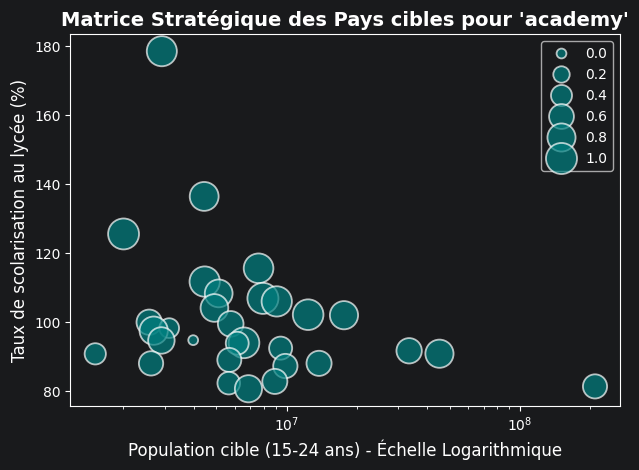

In [563]:
sns.scatterplot(data=most_interesting_countries,
                x='age_15_24',
                y='enrolment_ratio_upper_secondary',
                size='internet_per_100',
                sizes=(50, 500),
                alpha=0.7,
                color='teal')

# Echelle log pour eviter que le graphique soit écrasé a cause des outliner Inde et Chine sur l'indicateur age_15_24
plt.xscale('log')

plt.title("Matrice Stratégique des Pays cibles pour 'academy'", fontsize=14, fontweight='bold')
plt.xlabel("Population cible (15-24 ans) - Échelle Logarithmique", fontsize=12)
plt.ylabel("Taux de scolarisation au lycée (%)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

Le résultat n'est pas très visuel la quasi totalité des pays ayant la même couverture internet (sauf outliners)

In [555]:
print(most_interesting_countries['internet_per_100'].describe())

most_interesting_countries

# Malgré tout cela nous permet de voir qu'on a un outliner a 0, la Corée du nord. On ne garde que les pays ayant une couverture intéréssante (50% de la population)
#most_interesting_countries = most_interesting_countries.loc[most_interesting_countries['internet_per_100'] > 50]#

count   31.00
mean    65.85
std     21.54
min      0.00
25%     53.60
50%     66.01
75%     83.09
max     94.78
Name: internet_per_100, dtype: float64


,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score,internet_per_100
Country Name,,,,,,
Australia,178.56,2920804.40,0.01,1.00,0.50,88.24
Spain,136.44,4436945.40,0.01,0.57,0.29,80.56
Netherlands,125.56,2002184.00,0.00,0.46,0.23,93.96
France,115.59,7588616.60,0.03,0.36,0.19,85.62
Canada,111.74,4459604.40,0.01,0.32,0.17,89.84
Saudi Arabia,108.31,5119918.20,0.02,0.28,0.15,73.75
United Kingdom,106.87,7923198.00,0.03,0.27,0.15,94.78
Germany,105.99,9080370.20,0.04,0.26,0.15,89.65
Poland,104.09,4908971.60,0.02,0.24,0.13,73.30


In [558]:
# On recalcule la moyenne pondérée avec ce nouvel indicateur
most_interesting_countries['internet_per_100'] = scaler.fit_transform(most_interesting_countries[['internet_per_100']])
most_interesting_countries['global_score'] = (most_interesting_countries['population_score'] + most_interesting_countries['enrolment_ratio_score'] + most_interesting_countries['internet_per_100']) / 3

# Tri par score global décroissant
top_pays_finaux = most_interesting_countries.sort_values('global_score', ascending=False)

print(f'Nombre de pays sélectionnés : {len(top_pays_finaux)}')

Nombre de pays sélectionnés : 31


Voici ma recommandation finale des pays ou aller essayer de s'implanter :


In [560]:
top_pays_finaux.head(10)

,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score,internet_per_100
Country Name,,,,,,
Australia,178.56,2920804.40,0.01,1.00,0.65,0.93
China,81.34,210099514.80,1.00,0.01,0.52,0.56
Netherlands,125.56,2002184.00,0.00,0.46,0.48,0.99
Spain,136.44,4436945.40,0.01,0.57,0.48,0.85
United Kingdom,106.87,7923198.00,0.03,0.27,0.43,1.00
France,115.59,7588616.60,0.03,0.36,0.43,0.90
Canada,111.74,4459604.40,0.01,0.32,0.43,0.95
Japan,102.14,12379060.00,0.05,0.22,0.41,0.97
Germany,105.99,9080370.20,0.04,0.26,0.41,0.95
